# **Part 3 : The international diversification strategy**

### ***3.a. Converting returns in USD***

In [1207]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

#### *Preliminary task : Data Wrangling*

    1. For exchanges rates

In [1208]:
# Create dataframe with conversion rate 
aud_to_usd = pd.read_csv('./data/EXUSAL.csv') # aud to usd
eur_to_usd = pd.read_csv('./data/EXUSEU.csv') # eur to usd
jpy_to_usd = pd.read_csv('./data/EXJPUS.csv') # usd to jpy
chf_to_usd = pd.read_csv('./data/EXSZUS.csv') # usd to chf
gbp_to_usd = pd.read_csv('./data/EXUSUK.csv') # gbp to usd


# Renaming the columns for convenience 
aud_to_usd = aud_to_usd.rename(columns={'EXUSAL': 'exchange_rate'})
eur_to_usd = eur_to_usd.rename(columns={'EXUSEU': 'exchange_rate'})
jpy_to_usd = jpy_to_usd.rename(columns={'EXJPUS': 'exchange_rate'})
chf_to_usd = chf_to_usd.rename(columns={'EXSZUS': 'exchange_rate'})
gbp_to_usd = gbp_to_usd.rename(columns={'EXUSUK': 'exchange_rate'})

In [1209]:
# handle NaN values by linear interpolation
aud_to_usd['exchange_rate'] = aud_to_usd['exchange_rate'].interpolate(method='linear') 
eur_to_usd['exchange_rate'] = eur_to_usd['exchange_rate'].interpolate(method='linear')
jpy_to_usd['exchange_rate'] = 1/jpy_to_usd['exchange_rate'].interpolate(method='linear')
chf_to_usd['exchange_rate'] = 1/chf_to_usd['exchange_rate'].interpolate(method='linear')
gbp_to_usd['exchange_rate'] = gbp_to_usd['exchange_rate'].interpolate(method='linear')

In [1210]:
# Compute the returns from the exchange rates
aud_to_usd['FX_return'] = (aud_to_usd['exchange_rate'] - aud_to_usd['exchange_rate'].shift(1)) / aud_to_usd['exchange_rate'].shift(1)
eur_to_usd['FX_return'] = (eur_to_usd['exchange_rate'] - eur_to_usd['exchange_rate'].shift(1)) / eur_to_usd['exchange_rate'].shift(1)
jpy_to_usd['FX_return'] = (jpy_to_usd['exchange_rate'] - jpy_to_usd['exchange_rate'].shift(1)) / jpy_to_usd['exchange_rate'].shift(1)
chf_to_usd['FX_return'] = (chf_to_usd['exchange_rate'] - chf_to_usd['exchange_rate'].shift(1)) / chf_to_usd['exchange_rate'].shift(1)
gbp_to_usd['FX_return'] = (gbp_to_usd['exchange_rate'] - gbp_to_usd['exchange_rate'].shift(1)) / gbp_to_usd['exchange_rate'].shift(1)


In [1211]:
#drop NaN
aud_to_usd = aud_to_usd.dropna().reset_index(drop=True)
eur_to_usd = eur_to_usd.dropna().reset_index(drop=True)
jpy_to_usd = jpy_to_usd.dropna().reset_index(drop=True)
chf_to_usd = chf_to_usd.dropna().reset_index(drop=True)
gbp_to_usd = gbp_to_usd.dropna().reset_index(drop=True)


# Set the start date for all dataframes at 2002-05-01 to match japan
aud_to_usd = aud_to_usd[aud_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)
eur_to_usd = eur_to_usd[eur_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)
jpy_to_usd = jpy_to_usd[jpy_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)
chf_to_usd = chf_to_usd[chf_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)
gbp_to_usd = gbp_to_usd[gbp_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)

**Critical Assumption :** The observed return on 2002-05-01 is actually the return of month 2002-04 $\Rightarrow$ Need to shift the values by one month backwards and dropping the day value

In [1212]:
aud_to_usd['observation_date'] = (pd.to_datetime(aud_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
eur_to_usd['observation_date'] = (pd.to_datetime(eur_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
jpy_to_usd['observation_date'] = (pd.to_datetime(jpy_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
chf_to_usd['observation_date'] = (pd.to_datetime(chf_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
gbp_to_usd['observation_date'] = (pd.to_datetime(gbp_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')

# Check that all dataframes start at same date
# print(aud_to_usd.head())
# print(eur_to_usd.head())
# print(jpy_to_usd.head())
# print(chf_to_usd.head())
# print(gbp_to_usd.head())

In [1213]:
# Create Exchange rates dataframe and save it to csv format 
exchange_rates = pd.DataFrame({
    'date': aud_to_usd['observation_date'],
    'Australia': aud_to_usd['exchange_rate'],
    'Britain': gbp_to_usd['exchange_rate'],
    'France': eur_to_usd['exchange_rate'],
    'Germany': eur_to_usd['exchange_rate'],
    'Japan': jpy_to_usd['exchange_rate'],
    'Switzerland': chf_to_usd['exchange_rate'],
})

exchange_rates.to_csv('./data/exchange_rates.csv', index=False)
exchange_rates.head()

,date,Australia,Britain,France,Germany,Japan,Switzerland
0,2002-04,0.5498,1.4598,0.9170,0.9170,0.007913,0.629366
1,2002-05,0.5682,1.4837,0.9561,0.9561,0.008111,0.649393
2,2002-06,0.5538,1.5565,0.9935,0.9935,0.008482,0.679440
3,2002-07,0.5413,1.5368,0.9781,0.9781,0.008404,0.667913
4,2002-08,0.5465,1.5563,0.9806,0.9806,0.008259,0.669748


In [1214]:
# Create FX returns dataframe and save it to csv format 
fx_returns = pd.DataFrame({
    'date': aud_to_usd['observation_date'],
    'Australia': aud_to_usd['FX_return'],
    'Britain': gbp_to_usd['FX_return'],
    'France': eur_to_usd['FX_return'],
    'Germany': eur_to_usd['FX_return'],
    'Japan': jpy_to_usd['FX_return'],
    'Switzerland': chf_to_usd['FX_return'],
})

fx_returns.to_csv('./data/fx_returns.csv', index=False)
fx_returns.head()

,date,Australia,Britain,France,Germany,Japan,Switzerland
0,2002-04,0.027280,0.011713,0.034989,0.034989,0.034792,0.041098
1,2002-05,0.033467,0.016372,0.042639,0.042639,0.025018,0.031820
2,2002-06,-0.025343,0.049067,0.039117,0.039117,0.045729,0.046270
3,2002-07,-0.022571,-0.012657,-0.015501,-0.015501,-0.009190,-0.016965
4,2002-08,0.009607,0.012689,0.002556,0.002556,-0.017223,0.002746


    2. For country indices

In [1215]:
# Load the stocks per country
world_data = pd.read_csv('./data/country_data.csv', sep=';')

australia = world_data[world_data.country == 'AUSTRALIA'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
france = world_data[world_data.country == 'FRANCE'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
germany = world_data[world_data.country == 'GERMANY'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
japan = world_data[world_data.country == 'JAPAN'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
switzerland = world_data[world_data.country == 'SWITZERLAND'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
britain = world_data[world_data.country == 'UNITED KINGDOM'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)

# Load the stocks for the US
usa = pd.read_csv('./data/crsp_value_weighted_returns.csv', sep=';').rename(columns={'vwretx': 'monthly_price_return', 'vwretd': 'monthly_total_return'})

**Important note :** Since observations are made on the last day of each month, that means that the return observed on 2002-01-31 corresponds to the return of month 2002-01

In [1216]:
# Only keep the month and the year 
australia['date'] = pd.to_datetime(australia['date']).dt.strftime('%Y-%m')
france['date'] = pd.to_datetime(france['date']).dt.strftime('%Y-%m')
japan['date'] = pd.to_datetime(japan['date']).dt.strftime('%Y-%m')
germany['date'] = pd.to_datetime(germany['date']).dt.strftime('%Y-%m')
switzerland['date'] = pd.to_datetime(switzerland['date']).dt.strftime('%Y-%m')
usa['date'] = pd.to_datetime(usa['date']).dt.strftime('%Y-%m')
britain['date'] = pd.to_datetime(britain['date']).dt.strftime('%Y-%m')

***Converting country indices monthly returns in USD***

In order to compute returns in USD, we use the formula :  $R_{USD} = (1+R_{foreign})\cdot(1+R_{FX})-1$  
Where $R_{USD}$ is the corresponding return in USD, $R_{foreign}$ is the monthly return in foreign currency, and $R_{FX}$ the return on the exchange rate of foreign currency in dollar units  
  
  
Furthermore, we assume that we only study the monthly total return, ie. the monthly returns computed accounting for dividends



In [1217]:
# Compute returns in USD

## Australia
australia = australia.merge(aud_to_usd, left_on='date', right_on='observation_date')
australia['monthly_total_return_USD'] = (1+australia['monthly_total_return'])*(1+australia['FX_return'])-1
#australia['monthly_price_return_USD'] = (1+australia['monthly_price_return'])*(1+australia['FX_return'])-1
australia = australia.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
australia

,date,monthly_total_return_USD
0,2002-04,0.012587
1,2002-05,0.033256
2,2002-06,-0.051421
3,2002-07,-0.059533
4,2002-08,0.025970
...,...,...
267,2024-07,0.035730
268,2024-08,0.021983
269,2024-09,0.022941
270,2024-10,-0.037250


In [1218]:
## France
france = france.merge(eur_to_usd, left_on='date', right_on='observation_date')
france['monthly_total_return_USD'] = (1+france['monthly_total_return'])*(1+france['FX_return'])-1
#france['monthly_price_return_USD'] = (1+france['monthly_price_return'])*(1+france['FX_return'])-1
france = france.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
france

,date,monthly_total_return_USD
0,2002-04,-0.010538
1,2002-05,0.013428
2,2002-06,-0.044850
3,2002-07,-0.117957
4,2002-08,-0.002077
...,...,...
267,2024-07,0.018647
268,2024-08,0.025529
269,2024-09,-0.010247
270,2024-10,-0.075214


In [1219]:
## Germany
germany = germany.merge(eur_to_usd, left_on='date', right_on='observation_date')
germany['monthly_total_return_USD'] = (1+germany['monthly_total_return'])*(1+germany['FX_return'])-1
#germany['monthly_price_return_USD'] = (1+germany['monthly_price_return'])*(1+germany['FX_return'])-1
germany = germany.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
germany

,date,monthly_total_return_USD
0,2002-04,-0.011617
1,2002-05,0.015840
2,2002-06,-0.032251
3,2002-07,-0.122706
4,2002-08,-0.000348
...,...,...
267,2024-07,0.019748
268,2024-08,0.025336
269,2024-09,0.007013
270,2024-10,-0.045202


In [1220]:
japan = japan.merge(jpy_to_usd, left_on='date', right_on='observation_date')
japan['monthly_total_return_USD'] = (1+japan['monthly_total_return'])*(1+japan['FX_return'])-1
#japan['monthly_price_return_USD'] = (1+japan['monthly_price_return'])*(1+japan['FX_return'])-1
japan = japan.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
japan

,date,monthly_total_return_USD
0,2002-04,0.056094
1,2002-05,0.061906
2,2002-06,-0.041866
3,2002-07,-0.066380
4,2002-08,-0.041213
...,...,...
267,2024-07,0.072474
268,2024-08,-0.001815
269,2024-09,-0.059865
270,2024-10,-0.008310


In [1221]:
switzerland = switzerland.merge(chf_to_usd, left_on='date', right_on='observation_date')
switzerland['monthly_total_return_USD'] = (1+switzerland['monthly_total_return'])*(1+switzerland['FX_return'])-1
#switzerland['monthly_price_return_USD'] = (1+switzerland['monthly_price_return'])*(1+switzerland['FX_return'])-1
switzerland = switzerland.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
switzerland

,date,monthly_total_return_USD
0,2002-04,0.036820
1,2002-05,0.034877
2,2002-06,-0.039197
3,2002-07,-0.147091
4,2002-08,0.007842
...,...,...
267,2024-07,0.050481
268,2024-08,0.017400
269,2024-09,-0.027682
270,2024-10,-0.052857


In [1222]:
britain = britain.merge(gbp_to_usd, left_on='date', right_on='observation_date')
britain['monthly_total_return_USD'] = (1+britain['monthly_total_return'])*(1+britain['FX_return'])-1
#britain['monthly_price_return_USD'] = (1+britain['monthly_price_return'])*(1+britain['FX_return'])-1
britain = britain.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
britain

,date,monthly_total_return_USD
0,2002-04,-0.001806
1,2002-05,0.004702
2,2002-06,-0.037508
3,2002-07,-0.101053
4,2002-08,0.015599
...,...,...
267,2024-07,0.039456
268,2024-08,0.029770
269,2024-09,-0.030240
270,2024-10,-0.040088


In [1223]:
usa = usa.iloc[3:-1].drop(columns='monthly_price_return').reset_index(drop=True)
usa

,date,monthly_total_return
0,2002-04,-0.049600
1,2002-05,-0.010510
2,2002-06,-0.070259
3,2002-07,-0.081125
4,2002-08,0.007949
...,...,...
267,2024-07,0.019878
268,2024-08,0.021572
269,2024-09,0.020969
270,2024-10,-0.008298


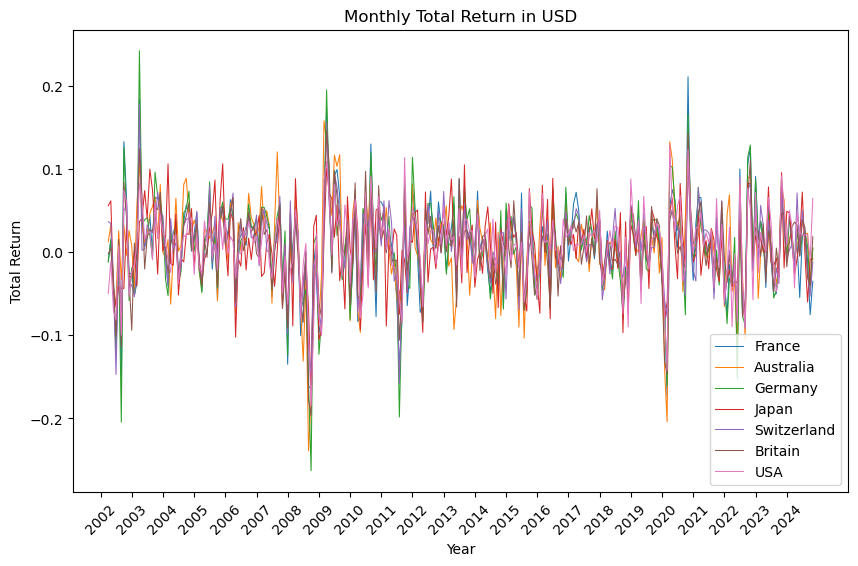

In [1224]:
# Plot returns in USD
plt.figure(figsize=(10,6))
plt.plot(pd.to_datetime(france['date']), france['monthly_total_return_USD'], label='France', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(australia['date']), australia['monthly_total_return_USD'], label='Australia', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(germany['date']), germany['monthly_total_return_USD'], label='Germany', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(japan['date']), japan['monthly_total_return_USD'], label='Japan', linestyle='-', linewidth=0.75)
plt.plot( pd.to_datetime(switzerland['date']), switzerland['monthly_total_return_USD'], label='Switzerland', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(britain['date']), britain['monthly_total_return_USD'], label='Britain', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(usa['date']), usa['monthly_total_return'], label='USA', linestyle='-', linewidth=0.75)  # Added USA to the plot
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()
plt.title('Monthly Total Return in USD')
plt.xlabel('Year')
plt.ylabel('Total Return')
plt.show()


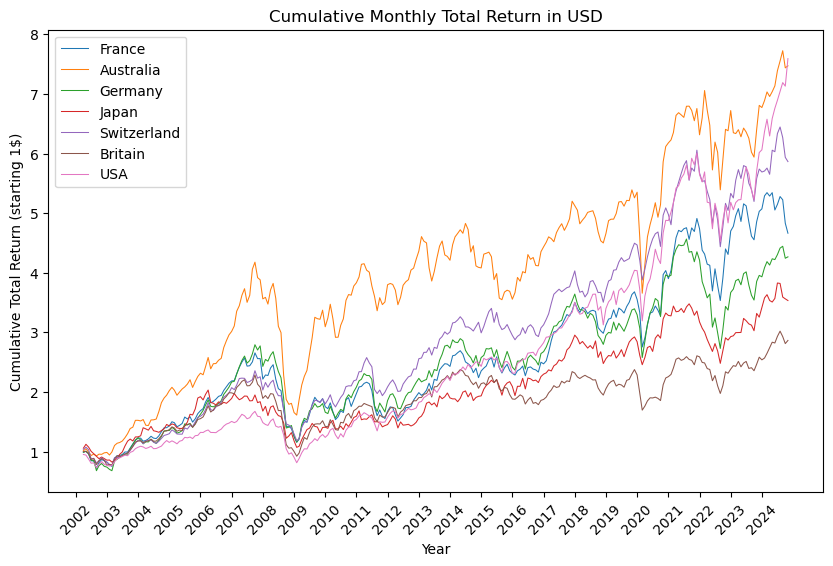

In [1225]:
plt.figure(figsize=(10,6))
plt.plot(pd.to_datetime(france['date']), (1 + france['monthly_total_return_USD']).cumprod(), label='France', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + australia['monthly_total_return_USD']).cumprod(), label='Australia', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + germany['monthly_total_return_USD']).cumprod(), label='Germany', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + japan['monthly_total_return_USD']).cumprod(), label='Japan', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + switzerland['monthly_total_return_USD']).cumprod(), label='Switzerland', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + britain['monthly_total_return_USD']).cumprod(), label='Britain', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + usa['monthly_total_return']).cumprod(), label='USA', linestyle='-', linewidth=0.75)  # Added USA to the plot
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()
plt.title('Cumulative Monthly Total Return in USD')
plt.xlabel('Year')
plt.ylabel('Cumulative Total Return (starting 1$)')
plt.show()

In [1226]:
usd_returns = pd.DataFrame({
    'date': usa['date'],
    'France': france['monthly_total_return_USD'],
    'Australia': australia['monthly_total_return_USD'],
    'Germany': germany['monthly_total_return_USD'],
    'Japan': japan['monthly_total_return_USD'],
    'Switzerland': switzerland['monthly_total_return_USD'],
    'Britain': britain['monthly_total_return_USD'],
    'USA': usa['monthly_total_return']
})

usd_returns.to_csv('./data/USD_monthly_returns.csv', index=False)
usd_returns

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,2002-04,-0.010538,0.012587,-0.011617,0.056094,0.036820,-0.001806,-0.049600
1,2002-05,0.013428,0.033256,0.015840,0.061906,0.034877,0.004702,-0.010510
2,2002-06,-0.044850,-0.051421,-0.032251,-0.041866,-0.039197,-0.037508,-0.070259
3,2002-07,-0.117957,-0.059533,-0.122706,-0.066380,-0.147091,-0.101053,-0.081125
4,2002-08,-0.002077,0.025970,-0.000348,-0.041213,0.007842,0.015599,0.007949
...,...,...,...,...,...,...,...,...
267,2024-07,0.018647,0.035730,0.019748,0.072474,0.050481,0.039456,0.019878
268,2024-08,0.025529,0.021983,0.025336,-0.001815,0.017400,0.029770,0.021572
269,2024-09,-0.010247,0.022941,0.007013,-0.059865,-0.027682,-0.030240,0.020969
270,2024-10,-0.075214,-0.037250,-0.045202,-0.008310,-0.052857,-0.040088,-0.008298


### B. Currency hedged 

In [1227]:
# Load the risk free rate and configure dates
r_f = pd.read_csv('./data/tbill.csv', sep=';').rename(columns={'mcaldt':'date', 'tmytm':'rate'})
r_f['rate'] = r_f['rate']/100
r_f['date'] = pd.to_datetime(r_f['date']).dt.strftime('%Y-%m')
r_f = r_f.iloc[3:].reset_index(drop=True)
r_f

,date,rate
0,2002-04,0.017528
1,2002-05,0.016895
2,2002-06,0.016666
3,2002-07,0.016997
4,2002-08,0.016565
...,...,...
268,2024-08,0.052564
269,2024-09,0.045916
270,2024-10,0.045024
271,2024-11,0.041699


In [1228]:
# Load the 3 month interbank rates 
aud_rate = pd.read_csv('./data/AUSTRALIA.csv')
eur_rate = pd.read_csv('./data/EUROPE.csv')
jpy_rate = pd.read_csv('./data/JAPAN.csv')
chf_rate = pd.read_csv('./data/SWITZERLAND.csv')
gbp_rate = pd.read_csv('./data/GREATBRITAIN.csv')
usd_rate = pd.read_csv('./data/USA.csv')

aud_rate = aud_rate.rename(columns={'IR3TIB01AUM156N':'borrowing_rate'}) 
eur_rate = eur_rate.rename(columns={'IR3TIB01EZM156N':'borrowing_rate'})
jpy_rate = jpy_rate.rename(columns={'IR3TIB01JPM156N':'borrowing_rate'})
chf_rate = chf_rate.rename(columns={'IR3TIB01CHM156N':'borrowing_rate'})
gbp_rate = gbp_rate.rename(columns={'IR3TIB01GBM156N':'borrowing_rate'})
usd_rate = usd_rate.rename(columns={'IR3TIB01USM156N':'borrowing_rate'})

aud_rate['observation_date'] = pd.to_datetime(aud_rate['observation_date']) - pd.DateOffset(months=1)
aud_rate['observation_date'] = aud_rate['observation_date'].dt.strftime('%Y-%m')
eur_rate['observation_date'] = pd.to_datetime(eur_rate['observation_date']) - pd.DateOffset(months=1)
eur_rate['observation_date'] = eur_rate['observation_date'].dt.strftime('%Y-%m')
jpy_rate['observation_date'] = pd.to_datetime(jpy_rate['observation_date']) - pd.DateOffset(months=1)
jpy_rate['observation_date'] = jpy_rate['observation_date'].dt.strftime('%Y-%m')
chf_rate['observation_date'] = pd.to_datetime(chf_rate['observation_date']) - pd.DateOffset(months=1)
chf_rate['observation_date'] = chf_rate['observation_date'].dt.strftime('%Y-%m')
gbp_rate['observation_date'] = pd.to_datetime(gbp_rate['observation_date']) - pd.DateOffset(months=1)
gbp_rate['observation_date'] = gbp_rate['observation_date'].dt.strftime('%Y-%m')
usd_rate['observation_date'] = pd.to_datetime(usd_rate['observation_date']) - pd.DateOffset(months=1)
usd_rate['observation_date'] = usd_rate['observation_date'].dt.strftime('%Y-%m')

aud_rate['borrowing_rate'] = aud_rate['borrowing_rate'].interpolate(method='linear')
eur_rate['borrowing_rate'] = eur_rate['borrowing_rate'].interpolate(method='linear')
jpy_rate['borrowing_rate'] = jpy_rate['borrowing_rate'].interpolate(method='linear')
chf_rate['borrowing_rate'] = chf_rate['borrowing_rate'].interpolate(method='linear')
gbp_rate['borrowing_rate'] = gbp_rate['borrowing_rate'].interpolate(method='linear')
usd_rate['borrowing_rate'] = usd_rate['borrowing_rate'].interpolate(method='linear')

aud_rate['borrowing_rate'] = aud_rate['borrowing_rate'] / 100
eur_rate['borrowing_rate'] = eur_rate['borrowing_rate'] / 100
jpy_rate['borrowing_rate'] = jpy_rate['borrowing_rate'] / 100
chf_rate['borrowing_rate'] = chf_rate['borrowing_rate'] / 100
gbp_rate['borrowing_rate'] = gbp_rate['borrowing_rate'] / 100
usd_rate['borrowing_rate'] = usd_rate['borrowing_rate'] / 100

aud_rate = aud_rate[aud_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
eur_rate = eur_rate[eur_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
jpy_rate = jpy_rate[jpy_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
chf_rate = chf_rate[chf_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
gbp_rate = gbp_rate[gbp_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
usd_rate = usd_rate[usd_rate['observation_date'] >= '2002-04'].reset_index(drop=True)

In [1229]:
# Compute excess returns
excess_ret = pd.DataFrame()
excess_ret['date'] = aud_rate['observation_date']

excess_ret['France'] = (eur_to_usd['exchange_rate'].shift(-1)/eur_to_usd['exchange_rate'])*(1+eur_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Australia'] = (aud_to_usd['exchange_rate'].shift(-1)/aud_to_usd['exchange_rate'])*(1+aud_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Germany'] = (eur_to_usd['exchange_rate'].shift(-1)/eur_to_usd['exchange_rate'])*(1+eur_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Japan'] = (jpy_to_usd['exchange_rate'].shift(-1)/jpy_to_usd['exchange_rate'])*(1+jpy_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Switzerland'] = (chf_to_usd['exchange_rate'].shift(-1)/chf_to_usd['exchange_rate'])*(1+chf_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Britain'] = (gbp_to_usd['exchange_rate'].shift(-1)/gbp_to_usd['exchange_rate'])*(1+gbp_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['USA'] = 0
excess_ret = excess_ret.dropna()
excess_ret['date'] = pd.to_datetime(excess_ret['date']).dt.strftime('%m-%Y')

excess_ret

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,04-2002,0.060589,0.065287,0.060589,0.007638,0.025625,0.040389,0
1,05-2002,0.057012,0.005972,0.057012,0.028570,0.040198,0.074792,0
2,06-2002,0.000171,0.008205,0.000171,-0.026199,-0.025005,0.009535,0
3,07-2002,0.018861,0.042383,0.018861,-0.033835,-0.007852,0.035760,0
4,08-2002,0.016134,0.038703,0.016134,-0.039655,-0.011537,0.023089,0
...,...,...,...,...,...,...,...,...
266,06-2024,0.000285,-0.010848,0.000285,0.025631,-0.001296,0.003924,0
267,07-2024,-0.007831,0.010159,-0.007831,-0.025436,-0.027771,0.020106,0
268,08-2024,-0.033731,-0.015197,-0.033731,-0.092438,-0.054917,-0.014159,0
269,09-2024,-0.040479,-0.028904,-0.040479,-0.068566,-0.059704,-0.023195,0


In [1230]:
# Calculate the difference between all columns except 'date'
hedged_returns = usd_returns.drop(columns=['date']).subtract(excess_ret.drop(columns=['date']))
hedged_returns['date'] = usd_returns.date
hedged_returns = hedged_returns[['date', 'France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']]
hedged_returns = hedged_returns.dropna()
hedged_returns.to_csv('./data/hedged_returns.csv', index=False)

hedged_returns

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,2002-04,-0.071127,-0.052699,-0.072206,0.048456,0.011195,-0.042195,-0.049600
1,2002-05,-0.043584,0.027284,-0.041172,0.033336,-0.005320,-0.070090,-0.010510
2,2002-06,-0.045020,-0.059626,-0.032422,-0.015667,-0.014192,-0.047043,-0.070259
3,2002-07,-0.136817,-0.101916,-0.141567,-0.032545,-0.139239,-0.136813,-0.081125
4,2002-08,-0.018210,-0.012733,-0.016481,-0.001558,0.019380,-0.007490,0.007949
...,...,...,...,...,...,...,...,...
266,2024-06,-0.054761,0.024602,-0.003400,-0.008334,-0.002760,-0.008618,0.026073
267,2024-07,0.026478,0.025571,0.027579,0.097910,0.078252,0.019350,0.019878
268,2024-08,0.059260,0.037179,0.059067,0.090624,0.072317,0.043929,0.021572
269,2024-09,0.030233,0.051845,0.047493,0.008701,0.032022,-0.007045,0.020969


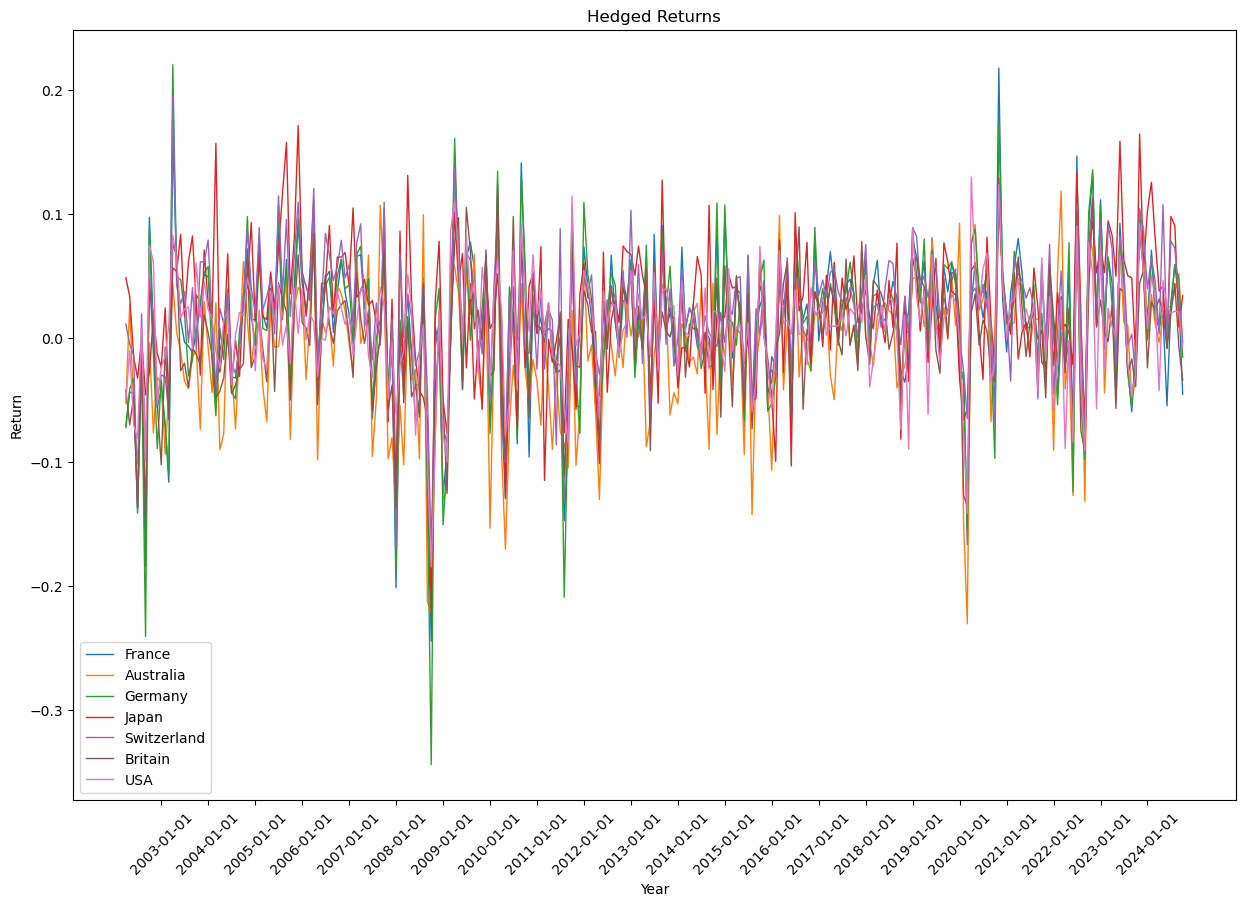

In [1231]:
# US remains USD returns as computed earlier
fig, ax = plt.subplots(figsize=(15, 10))  # Adjust figure size to be slightly smaller

# Convert 'date' column to datetime format for better plotting
hedged_returns['date'] = pd.to_datetime(hedged_returns['date'])

# Plotting each country's returns
for country in ['France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']:
    ax.plot(hedged_returns['date'], hedged_returns[country], linestyle='-', linewidth=1, label=country)

# Setting x-axis ticks to show unique years and inclining dates by 45 degrees
ax.set_xticks(pd.date_range(start=hedged_returns['date'].min(), end=hedged_returns['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Return')
ax.legend()
plt.show()


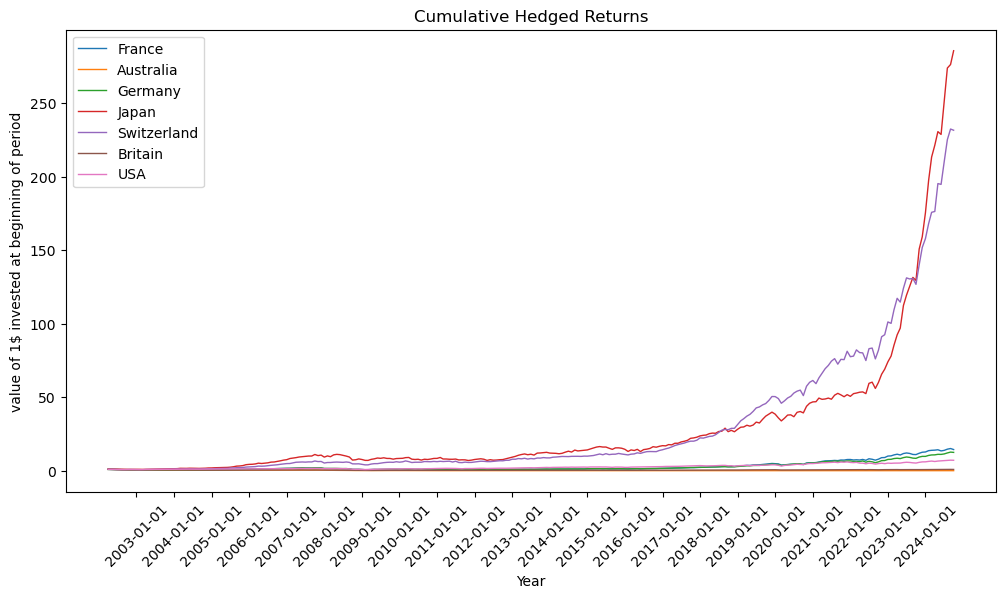

In [1232]:
hedged_returns_cumulative = (1 + hedged_returns.drop(columns=['date'])).cumprod()
hedged_returns_cumulative['date'] = hedged_returns['date']

fig, ax = plt.subplots(figsize=(12, 6))  

for country in ['France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']:
    ax.plot(hedged_returns_cumulative['date'], hedged_returns_cumulative[country], linestyle='-', linewidth=1, label=country)

ax.set_xticks(pd.date_range(start=hedged_returns_cumulative['date'].min(), end=hedged_returns_cumulative['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Cumulative Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('value of 1$ invested at beginning of period')
ax.legend()
plt.show()

### **C. International Diversification :** We consider 3 different approaches for a US investor to diversify internationally

##### ***1. Portfolio of equally weighted indices***

    Using currency hedged returns

In [1233]:
# hedged returns
equally_weighted_hedged = pd.DataFrame()
equally_weighted_hedged['date'] = hedged_returns['date']
equally_weighted_hedged['returns'] = hedged_returns.drop(columns='date').sum(axis=1)/6 #annualized returns
equally_weighted_hedged['excess_returns'] = equally_weighted_hedged['returns']- r_f['rate']/12

display(equally_weighted_hedged.excess_returns.describe())

sharpe_ratio_equally_hedged = (equally_weighted_hedged['excess_returns'].mean() / equally_weighted_hedged['excess_returns'].std())*np.sqrt(12) #assuming excess returns
print("Sharpe Ratio of Equally Weighted Hedged:", sharpe_ratio_equally_hedged)

count    271.000000
mean       0.009943
std        0.054448
min       -0.263101
25%       -0.013739
50%        0.017526
75%        0.043215
max        0.166055
Name: excess_returns, dtype: float64

Sharpe Ratio of Equally Weighted Hedged: 0.632604269963334


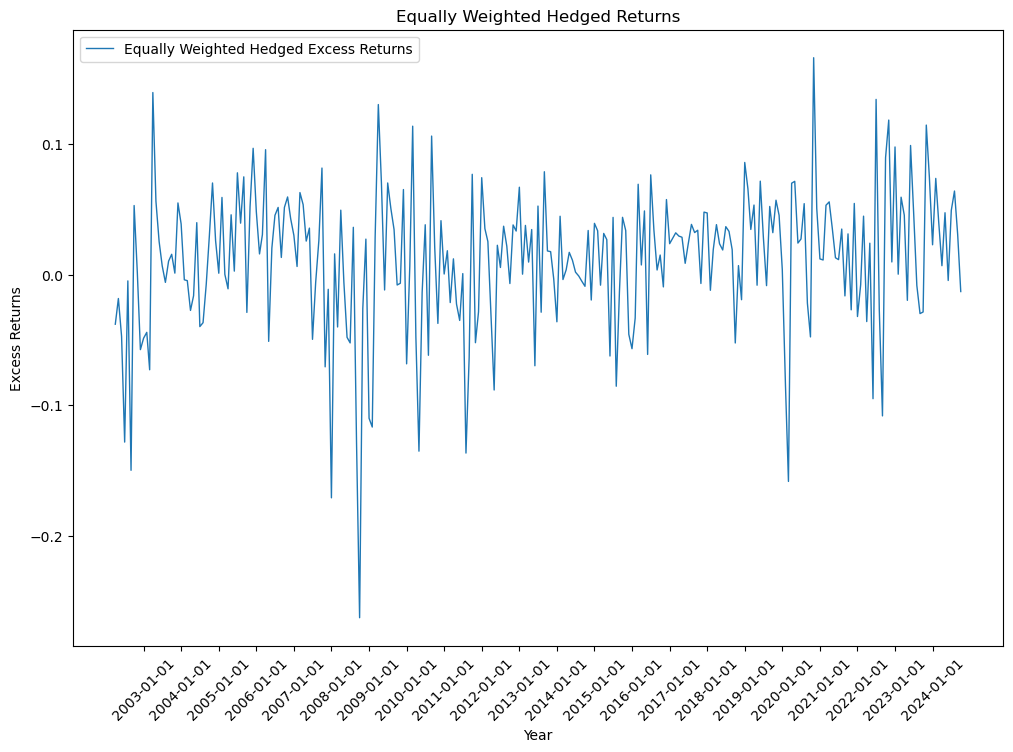

In [1234]:
fig, ax = plt.subplots(figsize=(12, 8))  

ax.plot(equally_weighted_hedged['date'], equally_weighted_hedged['returns'], linestyle='-', linewidth=1, label='Equally Weighted Hedged Excess Returns')

ax.set_xticks(pd.date_range(start=equally_weighted_hedged['date'].min(), end=equally_weighted_hedged['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Equally Weighted Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Excess Returns')
ax.legend()
plt.show()

    Using USD returns (unhedged for currency)

In [1235]:
# unhedged returns
equally_weighted_unhedged = pd.DataFrame()
equally_weighted_unhedged['date'] = usd_returns['date']
equally_weighted_unhedged['returns'] = usd_returns.drop(columns='date').sum(axis=1)/6
equally_weighted_unhedged['excess_returns'] = equally_weighted_unhedged['returns'] - r_f['rate']/12 #since r_f are annual returns


display(equally_weighted_unhedged.excess_returns.describe())

sharpe_ratio_equally_unhedged = (equally_weighted_unhedged['excess_returns'].mean() / equally_weighted_unhedged['excess_returns'].std())*np.sqrt(12) #assuning excess returns
print("Sharpe Ratio of Equally Weighted Unhedged:", sharpe_ratio_equally_unhedged)


count    272.000000
mean       0.007060
std        0.051285
min       -0.217735
25%       -0.018277
50%        0.011202
75%        0.038412
max        0.169533
Name: excess_returns, dtype: float64

Sharpe Ratio of Equally Weighted Unhedged: 0.47687965476470046


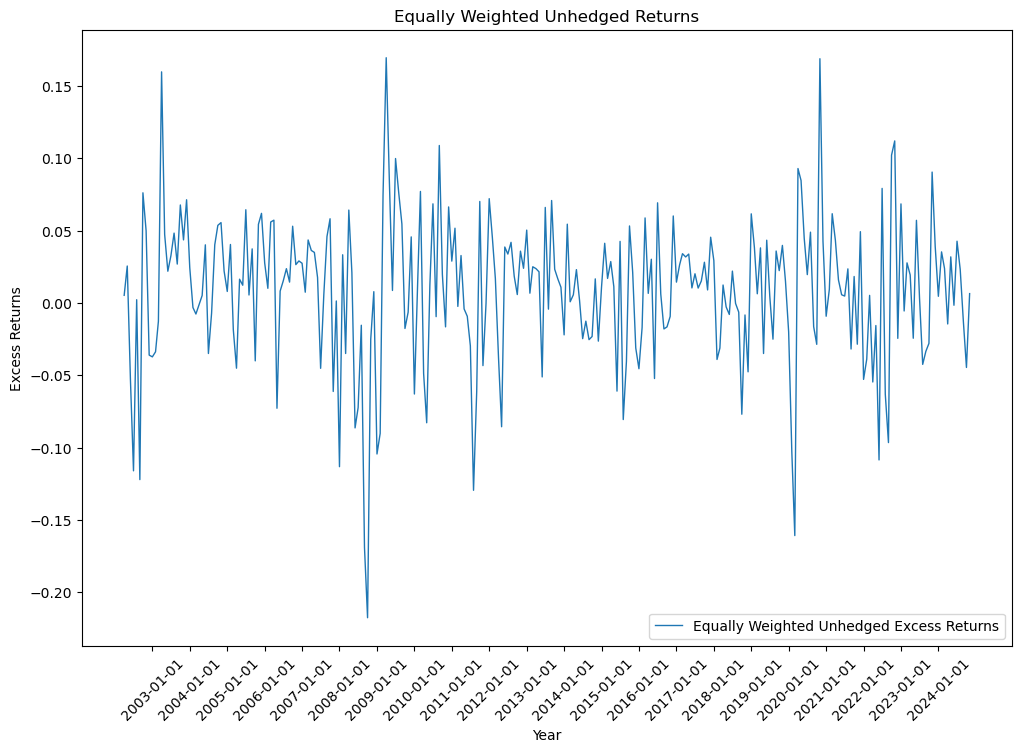

In [1236]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
equally_weighted_unhedged['date'] = pd.to_datetime(equally_weighted_unhedged['date'])
ax.plot(equally_weighted_unhedged['date'], equally_weighted_unhedged['returns'], linestyle='-', linewidth=1, label='Equally Weighted Unhedged Excess Returns')

ax.set_xticks(pd.date_range(start=equally_weighted_unhedged['date'].min(), end=equally_weighted_unhedged['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Equally Weighted Unhedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Excess Returns')
ax.legend()
plt.show()

#### ***2. Risk parity strategy***

    Using currency hedged returns

In [1237]:
# Hedged returns 
volatilities = hedged_returns.drop(columns='date').rolling(window=60).std().shift(1) #avoid look ahead bias
volatilities['date'] = hedged_returns['date'].dt.strftime('%Y-%m')
hedged_returns['date'] = hedged_returns['date'].dt.strftime('%Y-%m')
volatilities = volatilities.dropna()

# Compute risk_parity weights given by inverse of volatility
hedged_risk_parity = 1/volatilities.drop(columns='date')
hedged_risk_parity = hedged_risk_parity.div(hedged_risk_parity.sum(axis=1), axis=0) #normalize weights vector
hedged_risk_parity['date'] = volatilities.date
hedged_risk_parity['return'] = (hedged_risk_parity.drop(columns='date')*hedged_returns[hedged_returns['date'].astype(str).isin(hedged_risk_parity['date'].astype(str))]\
                                .drop(columns='date')).sum(axis=1)
hedged_risk_parity['excess_returns'] = hedged_risk_parity['return'] - r_f[r_f['date'].astype(str).isin(hedged_risk_parity['date'].astype(str))]['rate'].values/12

#display resulting deataframe
hedged_risk_parity = hedged_risk_parity.reset_index(drop=True)
hedged_risk_parity


,France,Australia,Germany,Japan,Switzerland,Britain,USA,date,return,excess_returns
0,0.121689,0.153501,0.105335,0.139056,0.131617,0.151437,0.197365,2007-04,0.042811,0.038849
1,0.122254,0.153710,0.105471,0.138410,0.129633,0.151008,0.199514,2007-05,0.022214,0.018302
2,0.122726,0.153790,0.105572,0.137780,0.129397,0.152738,0.197997,2007-06,0.027439,0.023663
3,0.122343,0.149998,0.104781,0.137691,0.128881,0.151885,0.204420,2007-07,-0.042091,-0.046346
4,0.122589,0.144076,0.104258,0.133971,0.134477,0.154658,0.205971,2007-08,-0.004694,-0.008154
...,...,...,...,...,...,...,...,...,...,...
206,0.132173,0.118859,0.130108,0.151813,0.160893,0.159561,0.146594,2024-06,-0.004018,-0.008486
207,0.131026,0.119618,0.130418,0.150677,0.160399,0.160282,0.147580,2024-07,0.043464,0.039000
208,0.131328,0.119873,0.130715,0.149590,0.159863,0.160742,0.147889,2024-08,0.055329,0.050948
209,0.131166,0.119939,0.130612,0.149776,0.159065,0.160966,0.148477,2024-09,0.024763,0.020937


In [1238]:
display(hedged_risk_parity['excess_returns'].describe())
sharpe_ratio_hedged_div = (hedged_risk_parity['excess_returns'].mean() / hedged_risk_parity['return'].std())*np.sqrt(12) 
print("Sharpe Ratio of Hedged Risk Parity:", sharpe_ratio_hedged_div)

count    211.000000
mean       0.008650
std        0.046923
min       -0.220971
25%       -0.013853
50%        0.017012
75%        0.037150
max        0.142176
Name: excess_returns, dtype: float64

Sharpe Ratio of Hedged Risk Parity: 0.6356870948014519


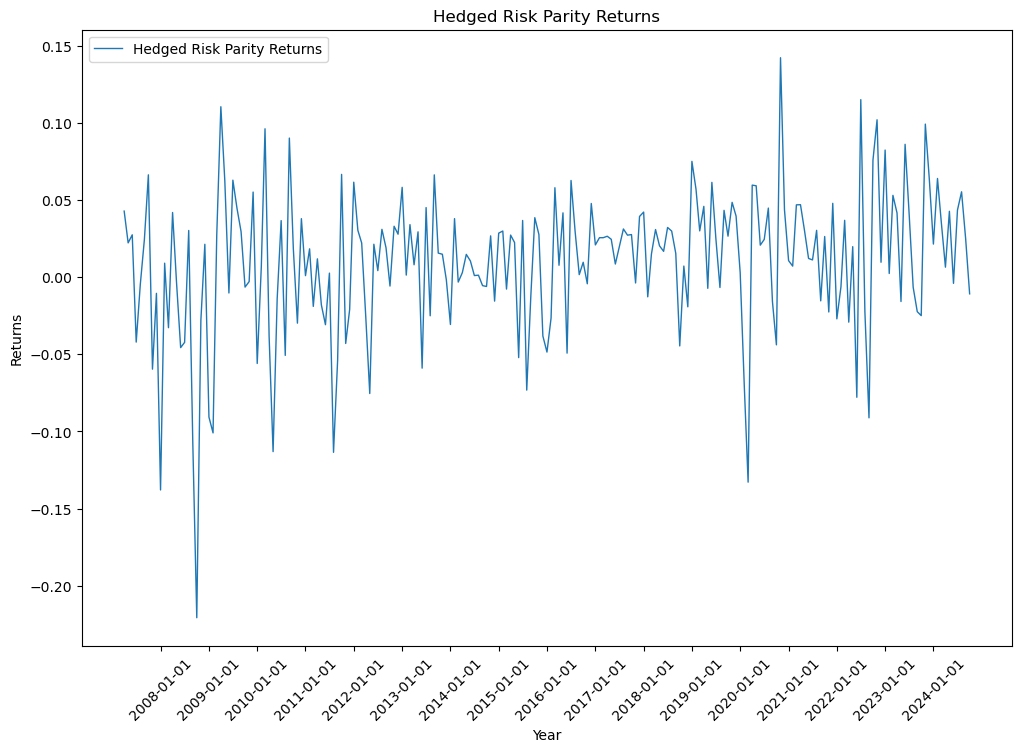

In [1239]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
hedged_risk_parity['date'] = pd.to_datetime(hedged_risk_parity['date'])
ax.plot(hedged_risk_parity['date'], hedged_risk_parity['return'], linestyle='-', linewidth=1, label='Hedged Risk Parity Returns')

ax.set_xticks(pd.date_range(start=hedged_risk_parity['date'].min(), end=hedged_risk_parity['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Hedged Risk Parity Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

    Unhedged USD returns

In [1240]:
# Unhedged Risk parity 
volatilities = usd_returns.drop(columns='date').rolling(window=60).std().shift(1) #avoid look ahead bias
#usd_returns['date'] = usd_returns['date'].dt.strftime('%Y-%m')
volatilities['date'] = usd_returns.date
volatilities = volatilities.dropna()

unhedged_risk_parity = 1/volatilities.drop(columns='date')
unhedged_risk_parity = unhedged_risk_parity.div(unhedged_risk_parity.sum(axis=1), axis=0)
unhedged_risk_parity['date'] = volatilities.date

unhedged_risk_parity['return'] = (unhedged_risk_parity.drop(columns='date')*usd_returns[usd_returns['date'].isin(unhedged_risk_parity['date'])].drop(columns='date')).sum(axis=1)
unhedged_risk_parity['excess_returns'] = unhedged_risk_parity['return'] - r_f[r_f['date'].astype(str).isin(unhedged_risk_parity['date'].astype(str))]['rate'].values/12
unhedged_risk_parity = unhedged_risk_parity.reset_index(drop=True)
unhedged_risk_parity

,France,Australia,Germany,Japan,Switzerland,Britain,USA,date,return,excess_returns
0,0.125573,0.161570,0.105757,0.143876,0.136415,0.148333,0.178476,2007-04,0.030036,0.026074
1,0.125115,0.161166,0.105315,0.143950,0.135555,0.148050,0.180849,2007-05,0.030247,0.026335
2,0.124926,0.160521,0.105108,0.145621,0.135689,0.147939,0.180196,2007-06,0.013669,0.009892
3,0.124047,0.162225,0.103652,0.144491,0.134413,0.146914,0.184257,2007-07,-0.038338,-0.042592
4,0.124363,0.154817,0.103025,0.141985,0.142856,0.147371,0.185582,2007-08,0.005084,0.001624
...,...,...,...,...,...,...,...,...,...,...
207,0.124078,0.124363,0.121258,0.172344,0.164897,0.153532,0.139528,2024-07,0.038798,0.034334
208,0.124720,0.124717,0.121983,0.170245,0.164469,0.153714,0.140152,2024-08,0.019168,0.014788
209,0.124442,0.124438,0.121791,0.171634,0.164264,0.153302,0.140129,2024-09,-0.014086,-0.017912
210,0.124736,0.124647,0.122239,0.170137,0.163724,0.154145,0.140373,2024-10,-0.036962,-0.040714


In [1241]:
display(unhedged_risk_parity['return'].describe())
sharpe_ratio_unhedged_div = unhedged_risk_parity['excess_returns'].mean() / unhedged_risk_parity['return'].std() 
print("Sharpe Ratio of Unhedged Risk Parity:", sharpe_ratio_unhedged_div)

count    212.000000
mean       0.005125
std        0.044684
min       -0.185542
25%       -0.019262
50%        0.008595
75%        0.030591
max        0.143800
Name: return, dtype: float64

Sharpe Ratio of Unhedged Risk Parity: 0.09213270146225731


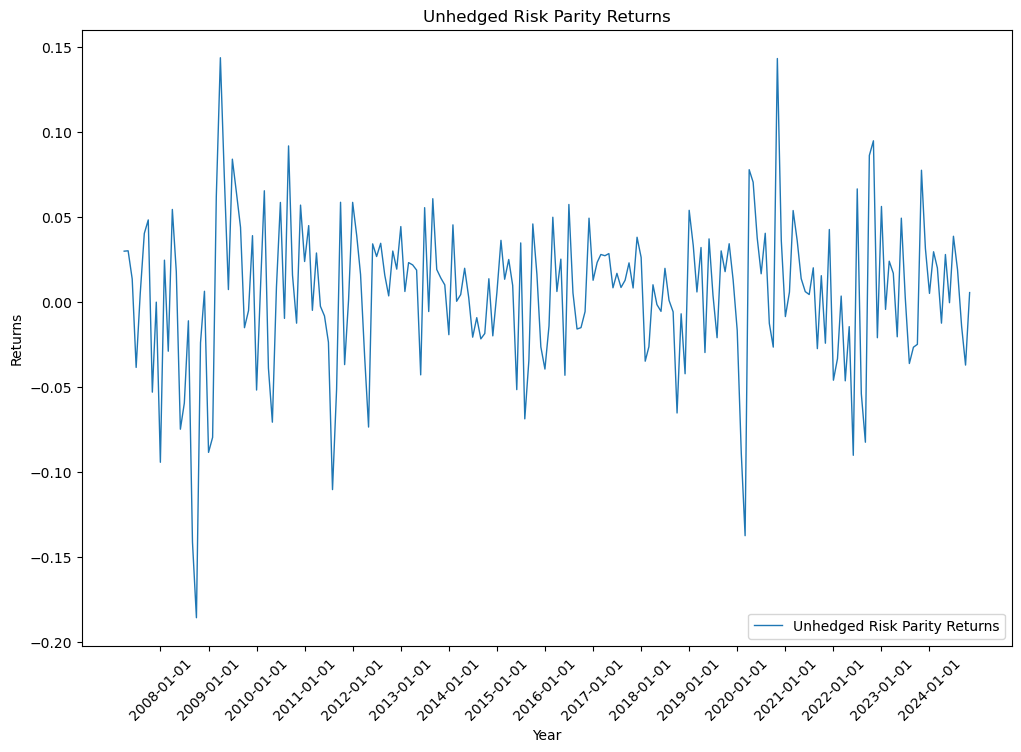

In [1242]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
unhedged_risk_parity['date'] = pd.to_datetime(unhedged_risk_parity['date'])
ax.plot(unhedged_risk_parity['date'], unhedged_risk_parity['return'], linestyle='-', linewidth=1, label='Unhedged Risk Parity Returns')

ax.set_xticks(pd.date_range(start=unhedged_risk_parity['date'].min(), end=unhedged_risk_parity['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Unhedged Risk Parity Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

##### ***MVE portfolio* (assuming risk aversion = 1)**

    For currency hedged returns

**Important note :** the weights at time t are chosen at time t-1 ! In order to avoid any issues, we use our own rolling window

**2nd important note :** Rolling windows for 2009 comprise a period of crisis (2008) that yields to eratic returns. Therefore, we add a penalty epsilon for the affected window for the weights to remain stable

In [1243]:
# Unhedged returns
import numpy as np
import pandas as pd

# 1. Drop the date column to get just the returns matrix
rets = hedged_returns.drop(columns='date')   # shape T×7
risk_free = r_f.drop(columns='date')

# 2. Prepare an empty DataFrame for the MV weights (same shape)
tangency_weights_hedged = pd.DataFrame(
    np.nan,
    index=rets.index,
    columns=rets.columns
)

window = 60

for t in range(window, len(rets)):
    # take the past 60 months of returns, ending at t−1
    window_rets = rets.iloc[t-window:t]                   # shape (window × 7)
    window_rf   = risk_free.iloc[t-window:t]               # shape (window,)
    # Subtract row‐wise by specifying axis=0:
    window_data = window_rets.sub(window_rf['rate']/12, axis=0)     # (60×7) array, divide by 12 since rate are yearly yields
    mu_t     = window_data.mean().values      # (7,)
    sigma_t  = window_data.cov().values       # (7×7)
    # raw MV weights  Σ^{-1} (μ-1rf)
    inv_sigma = np.linalg.inv(sigma_t)
    if t==86 or t==87: inv_sigma = np.linalg.inv(sigma_t + np.eye(sigma_t.shape[0]) * 10**(-2)) 
    w_raw = inv_sigma@mu_t
    # For Tangency Portfolio 
    tangency_weights_hedged.iloc[t] = w_raw/w_raw.sum()

    # for mve potfolio without leverage constraint
    #tangency_weights_hedged.iloc[t] = w_raw

tangency_weights_hedged = tangency_weights_hedged.dropna().reset_index(drop=True)

tangency_weights_hedged['date'] = hedged_returns['date'].iloc[window:].values

# reorder columns for ease of reading
cols = ['date'] + [c for c in tangency_weights_hedged.columns if c != 'date']
tangency_weights_hedged = tangency_weights_hedged[cols]

# Finally compute the strategy return
#    multiply each weight by its country return and sum across countries
rets_truncated = rets.iloc[window:].reset_index(drop=True)
risk_free_truncated = risk_free.iloc[window:].reset_index(drop=True)

tangency_weights_hedged['return'] = ((tangency_weights_hedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['rate']/12, axis=0)).sum(axis=1))
tangency_weights_hedged['excess_return'] = ((tangency_weights_hedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['rate']/12, axis=0)).sum(axis=1)) - risk_free_truncated['rate']/12
tangency_weights_hedged


,date,France,Australia,Germany,Japan,Switzerland,Britain,USA,return,excess_return
0,2007-04,1.220133,-1.536340,-2.085131,1.583631,3.885803,-3.762679,1.694584,0.355922,0.351960
1,2007-05,1.117415,-1.603790,-2.123117,1.671315,4.053734,-3.822639,1.707082,0.144976,0.141064
2,2007-06,1.114011,-1.575963,-1.964410,1.664764,3.752252,-3.718776,1.728122,-0.119607,-0.123383
3,2007-07,1.501321,-0.992209,-1.840459,1.352051,2.891473,-3.309449,1.397272,0.241560,0.237305
4,2007-08,1.087030,-0.587493,-1.555361,0.821822,2.211944,-2.098187,1.120245,0.145473,0.142013
...,...,...,...,...,...,...,...,...,...,...
206,2024-06,1.876180,0.122307,-0.842187,1.351132,1.792704,-1.947740,-1.352395,-0.136021,-0.140489
207,2024-07,1.078841,0.152820,-0.351593,1.400190,1.893683,-1.918962,-1.254979,0.241512,0.237048
208,2024-08,1.122822,0.159986,-0.354069,1.409871,1.906111,-1.973872,-1.270851,0.198679,0.194299
209,2024-09,1.005070,0.089280,-0.365317,1.387980,1.730688,-1.739463,-1.108238,0.070352,0.066526


In [1244]:
display(tangency_weights_hedged['excess_return'].describe())

sharpe_ratio_tangency_hedged = (tangency_weights_hedged['excess_return'].mean() / tangency_weights_hedged['excess_return'].std()) * np.sqrt(12)
print(f"Sharpe Ratio: {sharpe_ratio_tangency_hedged}")

count    211.000000
mean       0.089340
std        0.189080
min       -0.537945
25%       -0.012892
50%        0.070081
75%        0.183796
max        0.689855
Name: excess_return, dtype: float64

Sharpe Ratio: 1.6367748997057332


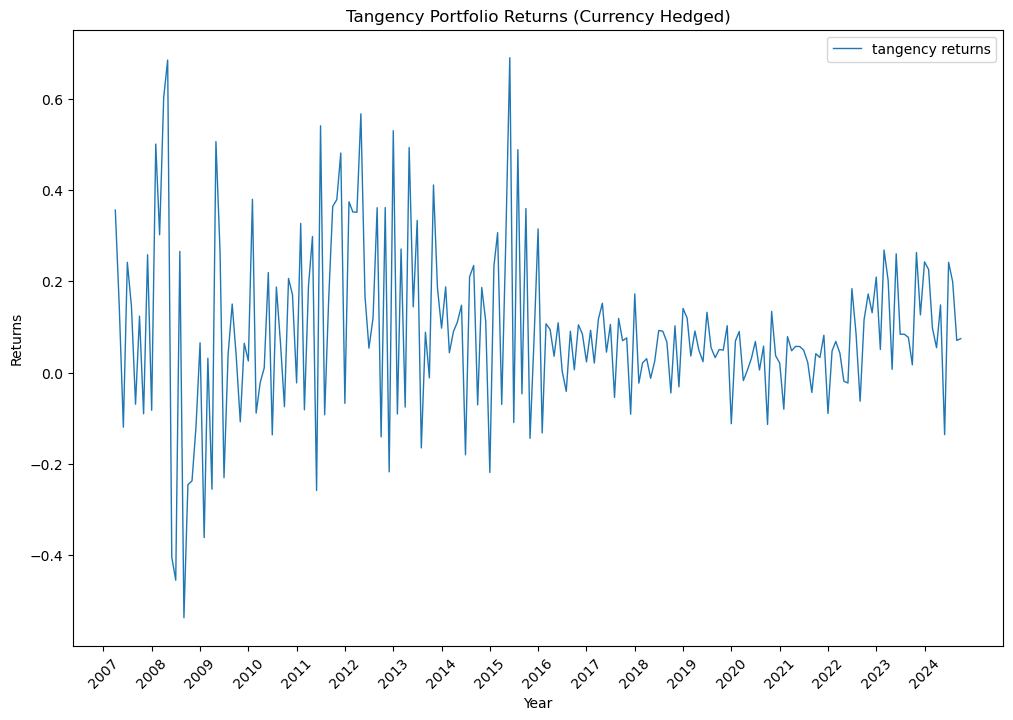

In [1245]:
fig, ax = plt.subplots(figsize=(12, 8))  

ax.plot(pd.to_datetime(tangency_weights_hedged['date']), tangency_weights_hedged['return'], linestyle='-', linewidth=1, label='tangency returns')
years = [pd.to_datetime(str(year)) for year in range(2007, 2025)]
plt.xticks(years, rotation=45)
ax.tick_params(axis='x', rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Tangency Portfolio Returns (Currency Hedged)')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

In [1246]:
# Unhedged returns
import numpy as np
import pandas as pd

# 1. Drop the date column to get just the returns matrix
rets = usd_returns.drop(columns='date')   # shape T×7
risk_free = r_f.drop(columns='date')

# 2. Prepare an empty DataFrame for the MV weights (same shape)
tangency_weights_unhedged = pd.DataFrame(
    np.nan,
    index=rets.index,
    columns=rets.columns
)

window = 60

for t in range(window, len(rets)):
    # take the past 60 months of returns, ending at t−1
    window_rets = rets.iloc[t-window:t]                   # shape (window × 7)
    window_rf   = risk_free.iloc[t-window:t]               # shape (window,)
    # Subtract row‐wise by specifying axis=0:
    window_data = window_rets.sub(window_rf['rate']/12, axis=0)     # (60×7) array, divide by 12 since rate are yearly yields
    mu_t     = window_data.mean().values      # (7,)
    sigma_t  = window_data.cov().values       # (7×7)

    # raw MV weights  Σ^{-1} (μ-1rf)
    inv_sigma = np.linalg.inv(sigma_t)
    if t>=93 and t<=105: inv_sigma = np.linalg.inv(sigma_t + np.eye(sigma_t.shape[0]) * 10**(-2)) 

    w_raw = inv_sigma@mu_t

    # For Tangency Portfolio 
    tangency_weights_unhedged.iloc[t] = w_raw/w_raw.sum()

    # for mve potfolio without leverage constraint
    #tangency_weights_unhedged.iloc[t] = w_raw

tangency_weights_unhedged = tangency_weights_unhedged.dropna().reset_index(drop=True)

tangency_weights_unhedged['date'] = usd_returns['date'].iloc[window:].values

# reorder columns for ease of reading
cols = ['date'] + [c for c in tangency_weights_unhedged.columns if c != 'date']
tangency_weights_unhedged = tangency_weights_unhedged[cols]

# Finally compute the strategy return
#    multiply each weight by its country return and sum across countries
rets_truncated = rets.iloc[window:].reset_index(drop=True)
risk_free_truncated = risk_free.iloc[window:].reset_index(drop=True)

tangency_weights_unhedged['return'] = ((tangency_weights_unhedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['rate']/12, axis=0)).sum(axis=1))
tangency_weights_unhedged['excess_return'] = ((tangency_weights_unhedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['rate']/12, axis=0)).sum(axis=1)) - risk_free_truncated['rate']/12
tangency_weights_unhedged.head(50)

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA,return,excess_return
0,2007-04,0.566266,1.578160,-0.274043,0.052737,0.037619,-0.053609,-0.907130,0.015599,0.011637
1,2007-05,0.543010,1.492446,-0.305722,-0.059419,0.071541,-0.178127,-0.563729,0.049610,0.045698
2,2007-06,0.499124,1.488353,-0.244036,-0.105145,-0.081415,-0.125191,-0.431690,0.051709,0.047933
3,2007-07,0.575504,1.217543,-0.448909,-0.068685,-0.024902,-0.197846,-0.052706,-0.077298,-0.081553
4,2007-08,0.463202,0.857438,-0.577910,-0.009731,0.413450,-0.247024,0.100574,0.021258,0.017798
5,2007-09,0.457501,0.884861,-0.533141,-0.006858,0.402873,-0.303191,0.097956,0.094184,0.091316
6,2007-10,0.374893,0.726451,-0.122025,0.056280,0.071394,-0.184386,0.077393,0.032645,0.029327
7,2007-11,0.232109,0.741434,-0.163616,0.086302,0.241334,-0.179108,0.041545,-0.060379,-0.063062
8,2007-12,0.092298,1.253908,0.565046,0.117380,-0.103489,-0.340094,-0.585048,0.010836,0.008455
9,2008-01,-0.288702,1.087002,0.908588,0.164234,-0.083636,-0.379644,-0.407843,-0.110890,-0.112277


In [1247]:
display(tangency_weights_unhedged['excess_return'].describe())

sharpe_ratio_tangency_unhedged = (tangency_weights_unhedged['excess_return'].mean() / tangency_weights_unhedged['excess_return'].std()) * np.sqrt(12)
print(f"Sharpe Ratio: {sharpe_ratio_tangency_unhedged}")

count    212.000000
mean      -0.001850
std        0.203295
min       -1.047197
25%       -0.062939
50%        0.013493
75%        0.063467
max        1.210827
Name: excess_return, dtype: float64

Sharpe Ratio: -0.031525613272788626


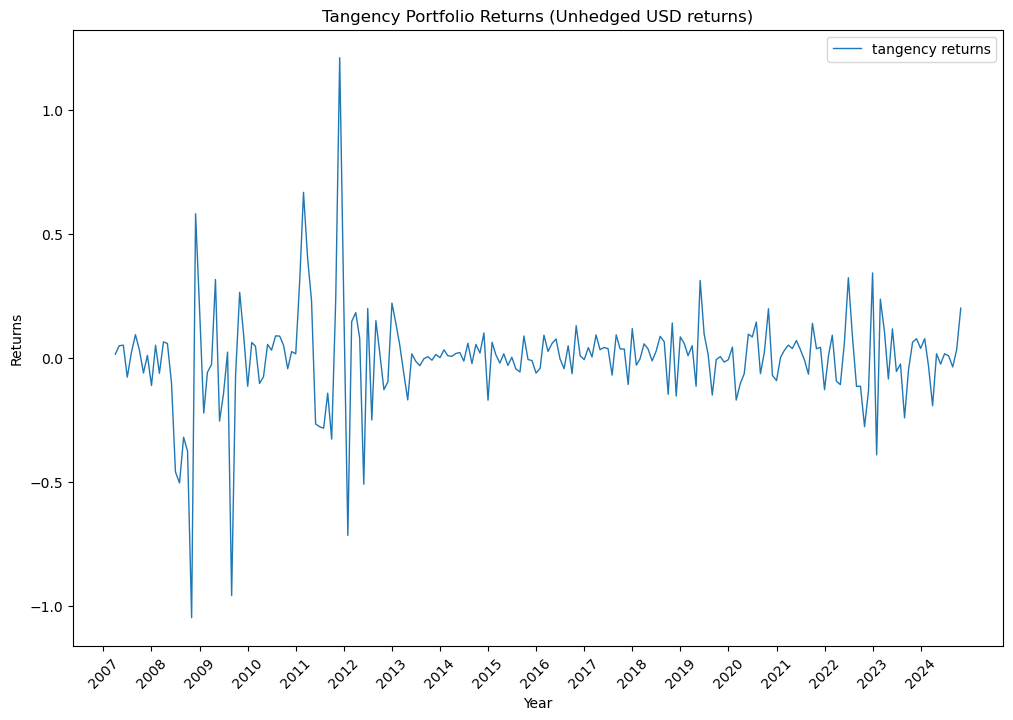

In [1248]:
fig, ax = plt.subplots(figsize=(12, 8))  

ax.plot(pd.to_datetime(tangency_weights_unhedged['date']), tangency_weights_unhedged['return'], linestyle='-', linewidth=1, label='tangency returns')
years = [pd.to_datetime(str(year)) for year in range(2007, 2025)]
plt.xticks(years, rotation=45)
ax.tick_params(axis='x', rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Tangency Portfolio Returns (Unhedged USD returns)')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

***Plotting the cumulative returns (cumulative wealth starting from 1 dollars)***

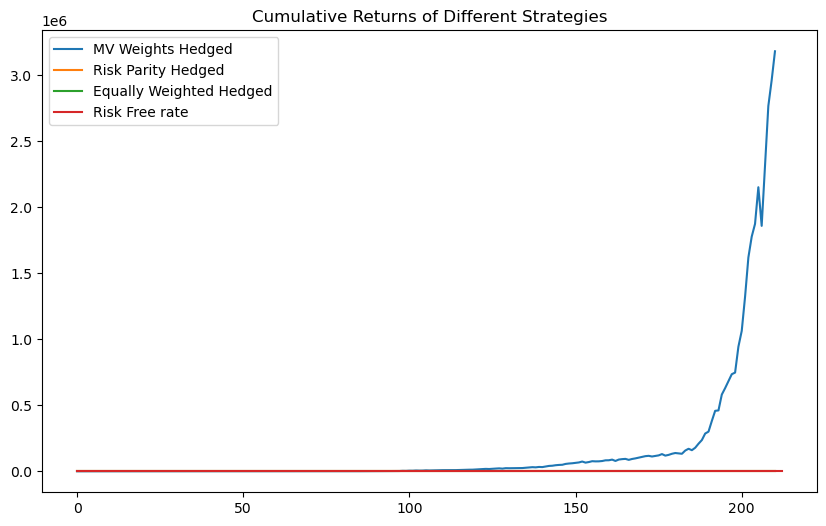

In [1249]:
import matplotlib.pyplot as plt

# Plot the returns of the three strategies
plt.figure(figsize=(10, 6))
(tangency_weights_hedged['return'] + 1).cumprod().plot(label='MV Weights Hedged')
(hedged_risk_parity['return'] + 1).cumprod().plot(label='Risk Parity Hedged')
(equally_weighted_hedged['returns'].iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Equally Weighted Hedged')
((r_f['rate']/12).iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Risk Free rate')

plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

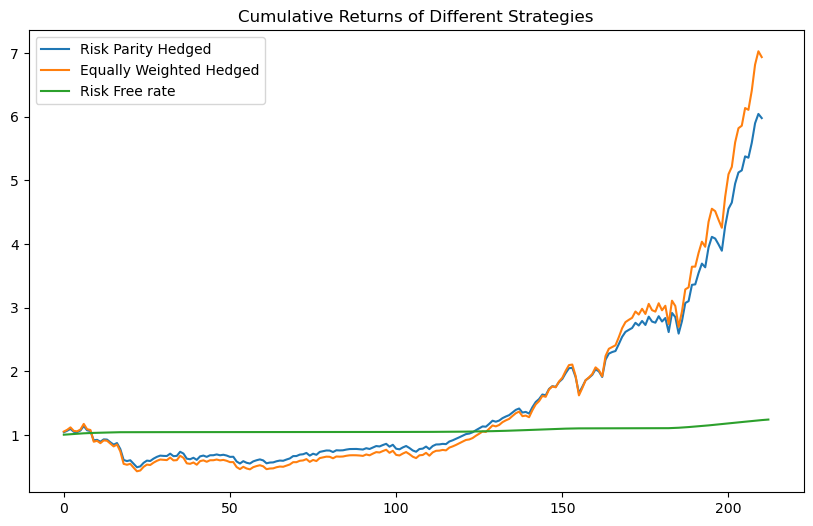

In [1254]:
# Omitting tangency weights :
plt.figure(figsize=(10, 6))
#(tangency_weights_hedged['return'] + 1).cumprod().plot(label='MV Weights Hedged')
(hedged_risk_parity['return'] + 1).cumprod().plot(label='Risk Parity Hedged')
(equally_weighted_hedged['returns'].iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Equally Weighted Hedged')
((r_f['rate']/12).iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Risk Free rate')

plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

***Ploting the cumulative sum of the excess returns***

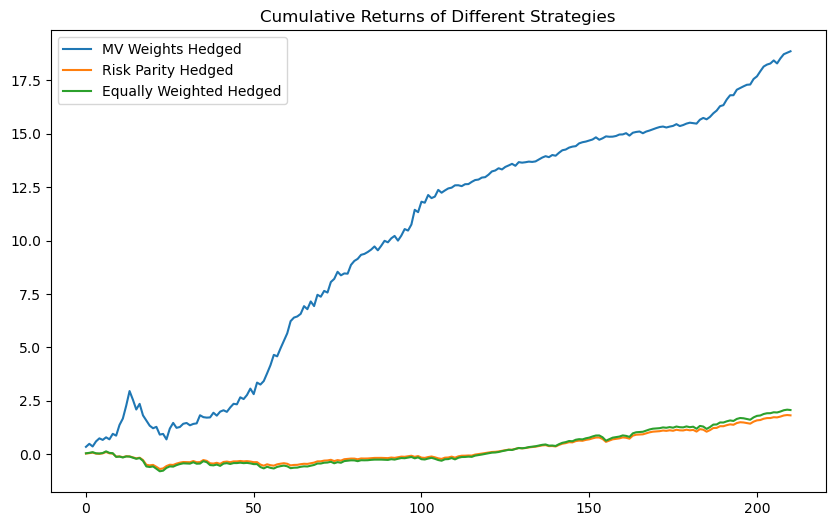

In [1250]:
import matplotlib.pyplot as plt

# Plot the returns of the three strategies
plt.figure(figsize=(10, 6))
tangency_weights_hedged['excess_return'].cumsum().plot(label='MV Weights Hedged')
hedged_risk_parity['excess_returns'].reset_index(drop=True).cumsum().plot(label='Risk Parity Hedged')
equally_weighted_hedged['excess_returns'].iloc[60:].reset_index(drop=True).cumsum().plot(label='Equally Weighted Hedged')
plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

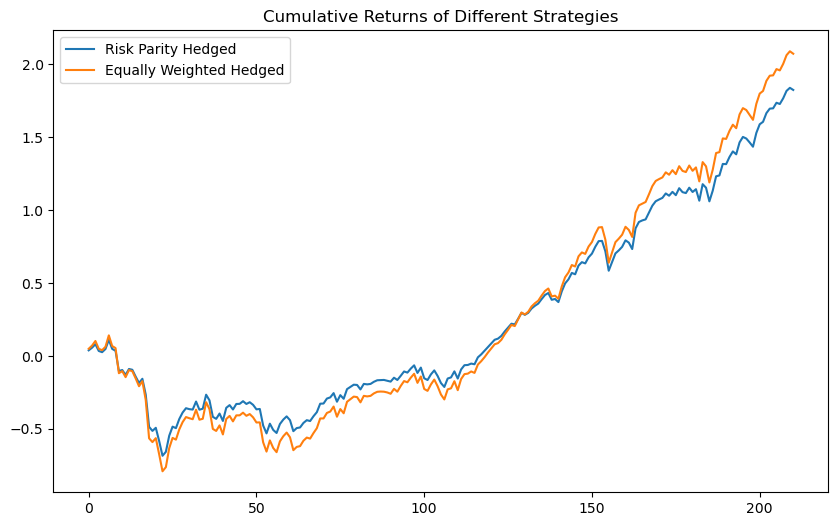

In [1255]:
# omitting tangenct portfolio 
# Plot the returns of the three strategies
plt.figure(figsize=(10, 6))
#tangency_weights_hedged['excess_return'].cumsum().plot(label='MV Weights Hedged')
hedged_risk_parity['excess_returns'].reset_index(drop=True).cumsum().plot(label='Risk Parity Hedged')
equally_weighted_hedged['excess_returns'].iloc[60:].reset_index(drop=True).cumsum().plot(label='Equally Weighted Hedged')
plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

***Plotting the Sharpe ratios of the different strategies***

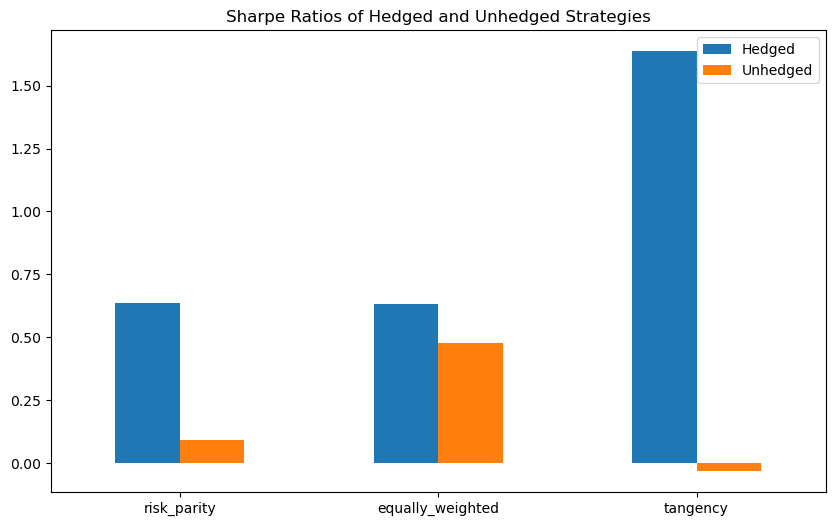

In [1251]:
sharpe_ratios = pd.DataFrame({'Hedged': {'risk_parity': sharpe_ratio_hedged_div, 'equally_weighted': sharpe_ratio_equally_hedged, 'tangency': sharpe_ratio_tangency_hedged}, 
                              'Unhedged': {'risk_parity':sharpe_ratio_unhedged_div, 'equally_weighted': sharpe_ratio_equally_unhedged, 'tangency': sharpe_ratio_tangency_unhedged}})

sharpe_ratios.plot(kind='bar', figsize=(10, 6))
plt.xticks(rotation=0)
plt.title('Sharpe Ratios of Hedged and Unhedged Strategies')
plt.show()



# 4. Equity Index Momentum Strategy

***4.a***

In [ ]:
# 1a. shift your series by 1 to drop the return in t-1 (the “skip” month)
# Ensure date column is not shifted
lagged = hedged_returns.drop(columns='date').shift(1)

# 1b. rolling‐window product over the prior 11 months
#     .rolling(window=11).apply(np.prod) gives ∏(1 + R) over each 11‐month blockr

cumret = lagged.add(1) \
               .rolling(window=11) \
               .apply(np.prod, raw=True) \
               .subtract(1)

print(cumret.head(20))

      France  Australia   Germany     Japan  Switzerland   Britain       USA
1        NaN        NaN       NaN       NaN          NaN       NaN       NaN
2        NaN        NaN       NaN       NaN          NaN       NaN       NaN
3        NaN        NaN       NaN       NaN          NaN       NaN       NaN
4        NaN        NaN       NaN       NaN          NaN       NaN       NaN
5        NaN        NaN       NaN       NaN          NaN       NaN       NaN
6        NaN        NaN       NaN       NaN          NaN       NaN       NaN
7        NaN        NaN       NaN       NaN          NaN       NaN       NaN
8        NaN        NaN       NaN       NaN          NaN       NaN       NaN
9        NaN        NaN       NaN       NaN          NaN       NaN       NaN
10       NaN        NaN       NaN       NaN          NaN       NaN       NaN
11       NaN        NaN       NaN       NaN          NaN       NaN       NaN
12 -0.479609  -0.415348 -0.531710 -0.131505    -0.305697 -0.463626 -0.195358

In [3702]:
ranks = cumret.rank(axis=1, method='first')    # lowest cumret→1, highest→N
ranks.head(20)

,France,Australia,Germany,Japan,Switzerland,Britain,USA
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3703]:
N = hedged_returns.drop(columns='date').shape[1]
print(N)

7


In [3704]:
w = ranks.subtract(4).div(N-1)
# this gives weights summing to zero and gross exposure=1
print(w.head(20))

      France  Australia   Germany     Japan  Switzerland   Britain       USA
1        NaN        NaN       NaN       NaN          NaN       NaN       NaN
2        NaN        NaN       NaN       NaN          NaN       NaN       NaN
3        NaN        NaN       NaN       NaN          NaN       NaN       NaN
4        NaN        NaN       NaN       NaN          NaN       NaN       NaN
5        NaN        NaN       NaN       NaN          NaN       NaN       NaN
6        NaN        NaN       NaN       NaN          NaN       NaN       NaN
7        NaN        NaN       NaN       NaN          NaN       NaN       NaN
8        NaN        NaN       NaN       NaN          NaN       NaN       NaN
9        NaN        NaN       NaN       NaN          NaN       NaN       NaN
10       NaN        NaN       NaN       NaN          NaN       NaN       NaN
11       NaN        NaN       NaN       NaN          NaN       NaN       NaN
12 -0.333333        0.0 -0.500000  0.500000     0.166667 -0.166667  0.333333

In [3705]:
# assume `w` is your weight-DataFrame aligned with hedged_returns
mom_return = (w * hedged_returns).sum(axis=1)

# put it all together
momentum = pd.DataFrame({
    'weight_'+col: w[col] for col in w.columns
})
momentum['momentum_return'] = mom_return.values
# Ensure date column is correctly aligned
momentum['date'] = hedged_returns['date']
momentum = momentum.dropna()

momentum = momentum.reset_index(drop=True)

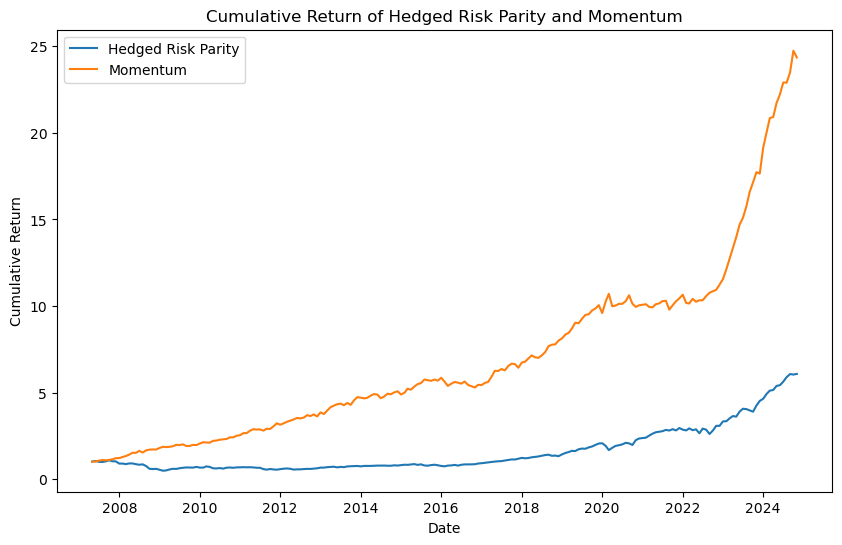

In [3706]:
import matplotlib.pyplot as plt

# Plotting the cumulative return of hedged risk parity and momentum
plt.figure(figsize=(10, 6))
plt.plot(hedged_risk_parity.date, (1 + hedged_risk_parity['return']).cumprod().reset_index(drop=True), label='Hedged Risk Parity')
plt.plot(momentum[momentum['date'] >= hedged_risk_parity['date'].min()].date, (1 + momentum[momentum['date'] >= hedged_risk_parity['date'].min()]['momentum_return']).cumprod().reset_index(drop=True), label='Momentum')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Return of Hedged Risk Parity and Momentum')
plt.legend()
plt.show()


In [3707]:
# Merge the momentum and hedged risk parity dataframes on the 'date' column
div_mom_returns = pd.merge(momentum[['date', 'momentum_return']], hedged_risk_parity[['date', 'return']], on='date', how='inner')

# Rename the 'return' column to 'DIV_return'
div_mom_returns = div_mom_returns.rename(columns={'return': 'DIV_return'})

# Display the merged dataframe
div_mom_returns

,date,momentum_return,DIV_return
0,2007-05-01,0.025983,0.026387
1,2007-06-01,0.000625,0.031988
2,2007-07-01,0.053572,-0.045981
3,2007-08-01,0.030946,-0.007421
4,2007-09-01,-0.016168,0.034854
...,...,...,...
206,2024-07-01,0.030841,0.037123
207,2024-08-01,-0.000424,0.046618
208,2024-09-01,0.025970,0.030019
209,2024-10-01,0.053110,-0.004912


***4.b***

In [3708]:
# Calculate the long strategy returns
long_strategy, short_strategy = pd.DataFrame(), pd.DataFrame()
short_strategy['date'], long_strategy['date'] = hedged_returns['date'], hedged_returns['date']

long_strategy['return'] = (w[w > 0] * hedged_returns.drop(columns='date')).sum(axis=1)

# Calculate the short strategy returns
short_strategy['return'] = (w[w < 0] * hedged_returns.drop(columns='date')).sum(axis=1)

long_strategy['excess_return'] = long_strategy['return'] - r_f[r_f['mcaldt'].isin(long_strategy['date'])]['tmytm']
short_strategy['excess_return'] = short_strategy['return'] - r_f[r_f['mcaldt'].isin(short_strategy['date'])]['tmytm']

long_strategy, short_strategy = long_strategy.iloc[11:].reset_index(drop=True), short_strategy.iloc[11:].reset_index(drop=True)

In [3709]:
print('long leg : \n', long_strategy['return'].describe())
long_strategy_sharpe = long_strategy['excess_return'].mean() / long_strategy['return'].std()
print('Long Strategy Sharpe Ratio: ', long_strategy_sharpe)

print('\nshort leg : \n', short_strategy['return'].describe())
short_strategy_sharpe = short_strategy['excess_return'].mean() / short_strategy['return'].std()
print('Short Strategy Sharpe Ratio: ', short_strategy_sharpe)

long leg : 
 count    260.000000
mean       0.020627
std        0.044106
min       -0.167901
25%       -0.004634
50%        0.026346
75%        0.048886
max        0.121511
Name: return, dtype: float64
Long Strategy Sharpe Ratio:  0.13671425186507744

short leg : 
 count    260.000000
mean      -0.000860
std        0.048650
min       -0.177121
25%       -0.027937
50%       -0.008005
75%        0.024015
max        0.193534
Name: return, dtype: float64
Short Strategy Sharpe Ratio:  -0.31772146507937976


In [3710]:
# Momentum mean and std
print('momentum strategy : \n', momentum['momentum_return'].describe())

momentum strategy : 
 count    260.000000
mean       0.019767
std        0.029402
min       -0.103402
25%        0.000513
50%        0.021963
75%        0.040192
max        0.092140
Name: momentum_return, dtype: float64


In [3711]:
# Momentum Sharpe Ratio
momentum['excess_return'] = momentum['momentum_return'].values - r_f['tmytm'].iloc[13:273].values
momentum_strategy_sharpe = momentum['excess_return'].mean() / momentum['momentum_return'].std()
print('Momentum Strategy Sharpe Ratio: ', momentum_strategy_sharpe)

Momentum Strategy Sharpe Ratio:  0.17132051465849135


In [3712]:
#Hypothesis testing
from scipy.stats import ttest_1samp

# Perform the t-test
t_stat, p_val = ttest_1samp(momentum['momentum_return'], 0)

print('T-statistic: ', t_stat)
print('P-value: ', p_val)

if p_val < 0.05:
    print('Reject the null hypothesis: The average return of momentum might be different than 0')
else:
    print('Fail to reject the null hypothesis: The average return of momentum is not statiscally significant')

T-statistic:  10.84012509963924
P-value:  8.010193329213559e-23
Reject the null hypothesis: The average return of momentum might be different than 0


***4.c***

In [ ]:
import statsmodels.api as sm

X = div_mom_returns['DIV_return']
y = div_mom_returns['momentum_return']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        momentum_return   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     5.743
Date:                Sun, 01 Jun 2025   Prob (F-statistic):             0.0174
Time:                        17:55:03   Log-Likelihood:                 462.40
No. Observations:                 211   AIC:                            -920.8
Df Residuals:                     209   BIC:                            -914.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0166      0.002      8.664      0.000       0.013       0.020
DIV_return    -0.0974      0.041     -2.396      0.017      -0.178      -0.017
==============================================================================
Omnibus:                        4.158   Durbin-Watson:                   2.128
Prob(Omnibus):                  0.125   Jarque-Bera (JB):                3.855
Skew:                          -0.325   Prob(JB):                        0.146
Kurtosis:                       3.131   Cond. No.                         21.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""